# Exploratory Data Anlaysis
#### This notebook is to show different distributions, correlations, and insights about the data.

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import plotly.express as px

In [68]:
# load data and preview
pd.set_option('display.max_columns', None)

df = pd.read_csv("jira_m2_accelerated.csv")
df

,issue_key,issue_type,priority_numeric,status,component,story_points,sprint,assignee_id,reporter_id,resolution,num_comments,num_attachments,watchers_count,time_to_resolution_hours,num_transitions,description_length,ticket_age_days,has_labels,parent_epic_id,parent_story_id,has_child_stories,has_child_subtasks,priority,created_date,updated_date,problem_statement,description,cause
0,USR-11480,Sub-task,5,Code Review,Payment Processing,3,Sprint 17,41,15,Unresolved,7,1,1,41.09,3,28,39,0,NaN,USR-10463,0,0,Highest,2025-09-19,2025-10-17,File Upload experiencing form validation failures,QA testing identified data completeness affect...,Application logic in file upload missing data ...
1,APP-11312,Story,5,Closed,API Services,5,Sprint 14,7,83,Done,5,3,1,71.18,3,37,40,1,WEB-10522,NaN,0,0,Highest,2025-09-18,2025-10-07,Password Reset showing timeout errors,Users reporting timeout errors in password res...,Frontend optimization needed for password reset
2,MOB-10305,Bug,3,In Progress,API Services,3,Sprint 6,48,40,Unresolved,5,1,4,45.39,4,27,63,1,NaN,NaN,0,0,Medium,2025-08-26,2025-09-11,Data Export showing performance slowdown,Users reporting performance slowdown in data e...,Frontend optimization needed for data export
3,WEB-11545,Epic,4,In Progress,Analytics,1,Sprint 13,91,176,Unresolved,4,1,2,25.08,2,51,9,1,NaN,NaN,1,0,High,2025-10-19,2025-10-28,Review Submission showing browser compatibility,Users reporting browser compatibility in revie...,Frontend optimization needed for review submis...
4,API-11716,Bug,5,To Do,Payment Processing,5,Sprint 8,102,61,Unresolved,3,0,1,88.71,1,44,69,0,NaN,NaN,0,0,Highest,2025-08-20,2025-09-13,Subscription Management experiencing text trun...,QA testing identified incorrect data affecting...,Application logic in subscription management m...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,USR-10277,Task,4,Code Review,API Services,3,Sprint 2,22,50,Unresolved,6,1,1,22.47,2,29,13,1,NaN,NaN,0,0,High,2025-10-15,2025-11-02,Data Export showing browser compatibility,Users reporting browser compatibility in data ...,Frontend optimization needed for data export
1996,WEB-11841,Task,3,In Progress,User Management,2,Sprint 4,25,39,Unresolved,6,3,2,104.21,1,15,62,0,NaN,NaN,0,0,Medium,2025-08-27,2025-09-20,Password Reset showing loading delays,Users reporting loading delays in password res...,Frontend optimization needed for password reset
1997,APP-10255,Task,1,Closed,Customer Portal,2,Sprint 17,79,80,Done,8,1,1,76.46,3,15,98,1,NaN,NaN,0,0,Lowest,2025-07-22,2025-07-23,Account Settings showing browser compatibility,Users reporting browser compatibility in accou...,Frontend optimization needed for account settings
1998,APP-11344,Task,2,Code Review,Payment Processing,2,Sprint 20,73,194,Unresolved,5,2,0,94.66,4,61,15,0,NaN,NaN,0,0,Low,2025-10-13,2025-10-22,Customer Profile experiencing text truncation,QA testing identified data inconsistency affec...,Application logic in customer profile missing ...


In [69]:
# data's shape
df.shape

(2000, 28)

In [70]:
# output all columns
df.columns

Index(['issue_key', 'issue_type', 'priority_numeric', 'status', 'component',
       'story_points', 'sprint', 'assignee_id', 'reporter_id', 'resolution',
       'num_comments', 'num_attachments', 'watchers_count',
       'time_to_resolution_hours', 'num_transitions', 'description_length',
       'ticket_age_days', 'has_labels', 'parent_epic_id', 'parent_story_id',
       'has_child_stories', 'has_child_subtasks', 'priority', 'created_date',
       'updated_date', 'problem_statement', 'description', 'cause'],
      dtype='object')

In [71]:
#Feature Analysis: Numerical vs Categorical
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(len(num_cols))
print(f"Numeric columns ({len(num_cols)}):", num_cols)

print(len(cat_cols))
print(f"Categorical columns ({len(cat_cols)}):", cat_cols)

14
Numeric columns (14): ['priority_numeric', 'story_points', 'assignee_id', 'reporter_id', 'num_comments', 'num_attachments', 'watchers_count', 'time_to_resolution_hours', 'num_transitions', 'description_length', 'ticket_age_days', 'has_labels', 'has_child_stories', 'has_child_subtasks']
14
Categorical columns (14): ['issue_key', 'issue_type', 'status', 'component', 'sprint', 'resolution', 'parent_epic_id', 'parent_story_id', 'priority', 'created_date', 'updated_date', 'problem_statement', 'description', 'cause']


In [72]:
# describe the data
df.describe(include="all")

,issue_key,issue_type,priority_numeric,status,component,story_points,sprint,assignee_id,reporter_id,resolution,num_comments,num_attachments,watchers_count,time_to_resolution_hours,num_transitions,description_length,ticket_age_days,has_labels,parent_epic_id,parent_story_id,has_child_stories,has_child_subtasks,priority,created_date,updated_date,problem_statement,description,cause
count,2000,2000,2000.000000,2000,2000,2000.000000,2000,2000.000000,2000.000000,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,396,130,2000.000000,2000.000000,2000,2000,2000,2000,2000,2000
unique,2000,5,NaN,7,10,NaN,21,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,87,108,NaN,NaN,5,120,146,326,1898,248
top,MOB-11860,Story,NaN,In Progress,Customer Portal,NaN,Sprint 14,NaN,NaN,Unresolved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MOB-10104,USR-10020,NaN,NaN,Medium,2025-08-04,2025-10-27,Product Search showing loading delays,Users reporting UI rendering issues in data ex...,Frontend optimization needed for account settings
freq,1,674,NaN,509,306,NaN,116,NaN,NaN,1491,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,3,NaN,NaN,736,27,29,22,6,76
mean,NaN,NaN,2.944000,NaN,NaN,4.073500,NaN,100.220500,99.763000,NaN,4.072000,0.916500,2.006000,71.972920,2.439000,35.193000,61.580000,0.605500,NaN,NaN,0.043500,0.054000,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,1.115565,NaN,NaN,3.424757,NaN,57.883367,57.352842,NaN,2.011676,1.153774,1.419849,19.798941,1.362794,17.341601,35.384539,0.488865,NaN,NaN,0.204031,0.226074,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,1.000000,NaN,1.000000,1.000000,NaN,0.000000,0.000000,0.000000,5.600000,1.000000,8.000000,1.000000,0.000000,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,2.000000,NaN,NaN,2.000000,NaN,50.000000,51.000000,NaN,3.000000,0.000000,1.000000,58.315000,1.000000,21.000000,30.000000,0.000000,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,3.000000,NaN,NaN,3.000000,NaN,100.000000,100.000000,NaN,4.000000,1.000000,2.000000,72.300000,2.000000,31.000000,63.000000,1.000000,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,4.000000,NaN,NaN,5.000000,NaN,150.000000,149.000000,NaN,5.000000,1.000000,3.000000,85.760000,3.000000,46.000000,93.000000,1.000000,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [73]:
df.info(max_cols=None)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   issue_key                 2000 non-null   object 
 1   issue_type                2000 non-null   object 
 2   priority_numeric          2000 non-null   int64  
 3   status                    2000 non-null   object 
 4   component                 2000 non-null   object 
 5   story_points              2000 non-null   int64  
 6   sprint                    2000 non-null   object 
 7   assignee_id               2000 non-null   int64  
 8   reporter_id               2000 non-null   int64  
 9   resolution                2000 non-null   object 
 10  num_comments              2000 non-null   int64  
 11  num_attachments           2000 non-null   int64  
 12  watchers_count            2000 non-null   int64  
 13  time_to_resolution_hours  2000 non-null   float64
 14  num_tran

In [74]:
# print the missing columns from prev code block
df[['parent_epic_id', 'parent_story_id',
       'has_child_stories', 'has_child_subtasks', 'priority', 'created_date',
       'updated_date', 'problem_statement', 'description', 'cause']].info(max_cols=None)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   parent_epic_id      396 non-null    object
 1   parent_story_id     130 non-null    object
 2   has_child_stories   2000 non-null   int64 
 3   has_child_subtasks  2000 non-null   int64 
 4   priority            2000 non-null   object
 5   created_date        2000 non-null   object
 6   updated_date        2000 non-null   object
 7   problem_statement   2000 non-null   object
 8   description         2000 non-null   object
 9   cause               2000 non-null   object
dtypes: int64(2), object(8)
memory usage: 156.4+ KB


In [75]:
# check if any rows are duplicated
df.duplicated().sum()

0

### Correlation Plots

In [76]:
# Select numeric columns only
numeric_data = df.select_dtypes(include=[np.number])

# Choose your target column
target_col = "time_to_resolution_hours"  # change this

# Compute correlation with the target column
corr_with_target = numeric_data.corr()[[target_col]].sort_values(by=target_col, ascending=False)

# Plot heatmap
heatmap_fig = px.imshow(
    corr_with_target,
    aspect="auto",
    color_continuous_scale="RdBu_r",
    title=f"Correlation with {target_col}"
)

heatmap_fig.update_xaxes(side="top")
heatmap_fig.show()

In [77]:
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder

# Copy and encode categorical columns
df_temp = df.copy()
le = LabelEncoder()

categorical_cols = ['issue_type', 'status', 'component', 'sprint', 'resolution', 'parent_epic_id', 'parent_story_id', 'priority', 'created_date', 'updated_date']

for col in categorical_cols:
    df_temp[col] = le.fit_transform(df_temp[col].astype(str))

# Fit a quick model
X = df_temp[categorical_cols]
y = df_temp['time_to_resolution_hours']
model = XGBRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Get importance
importance = pd.Series(model.feature_importances_, index=categorical_cols).sort_values(ascending=False)
print(importance)

updated_date       0.117200
parent_story_id    0.115652
created_date       0.115092
parent_epic_id     0.111514
resolution         0.109829
sprint             0.094377
component          0.090330
priority           0.088927
issue_type         0.083311
status             0.073769
dtype: float32


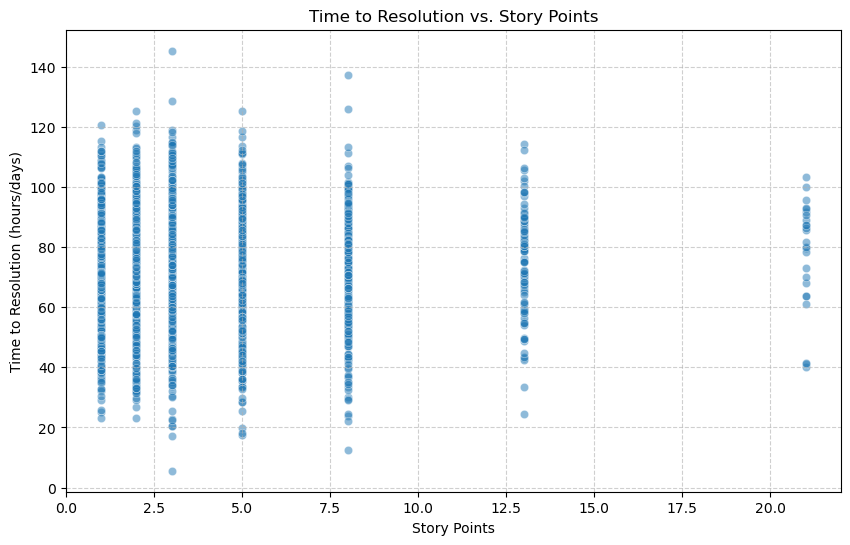

In [78]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='story_points', y='time_to_resolution_hours', alpha=0.5)

plt.title('Time to Resolution vs. Story Points')
plt.xlabel('Story Points')
plt.ylabel('Time to Resolution (hours/days)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

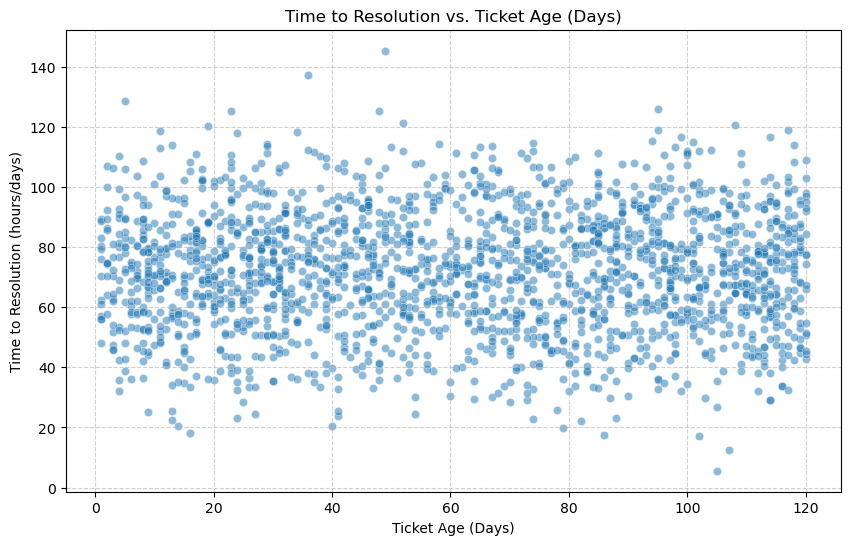

In [79]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='ticket_age_days', y='time_to_resolution_hours', alpha=0.5)

plt.title('Time to Resolution vs. Ticket Age (Days)')
plt.xlabel('Ticket Age (Days)')
plt.ylabel('Time to Resolution (hours/days)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Distribution of Features

In [80]:
# distribution of rows for each issue type
fig_issue_type = px.histogram(df, x='issue_type', title='Distribution of Issue Types')
fig_issue_type.show()

In [81]:
# distribution of rows for each resolution
fig_resolution = px.histogram(df, x='resolution', title='Distribution of Resolutions')
fig_resolution.show()

In [82]:
# distribution of rows for each component
fig_resolution = px.histogram(df, x='component', title='Distribution of Components')
fig_resolution.show()

In [83]:
# distribution of rows for each number of story points
fig_resolution = px.histogram(df, x='story_points', title='Distribution of Story Points')
fig_resolution.show()

In [84]:
# distribution of rows for each ticket age in days
fig_resolution = px.histogram(df, x='ticket_age_days', title='Distribution of Ticket Age (Days)')
fig_resolution.show()

### Sprints

In [85]:
df['sprint'].unique()

array(['Sprint 17', 'Sprint 14', 'Sprint 6', 'Sprint 13', 'Sprint 8',
       'Sprint 16', 'Sprint 15', 'Sprint 1', 'Sprint 7', 'Sprint 9',
       'Sprint 4', 'Sprint 12', 'Sprint 19', 'Sprint 10', 'Backlog',
       'Sprint 3', 'Sprint 5', 'Sprint 11', 'Sprint 2', 'Sprint 20',
       'Sprint 18'], dtype=object)

In [86]:
df['sprint'].value_counts()

sprint
Sprint 14    116
Sprint 18    108
Sprint 6     104
Sprint 5     104
Sprint 12    102
Sprint 2     101
Sprint 10     99
Sprint 17     98
Sprint 15     98
Sprint 7      96
Sprint 13     96
Sprint 3      94
Sprint 4      94
Sprint 16     92
Sprint 20     92
Sprint 8      91
Sprint 1      90
Backlog       86
Sprint 11     86
Sprint 19     83
Sprint 9      70
Name: count, dtype: int64

In [90]:
print(df.groupby('issue_type')['time_to_resolution_hours'].mean())
print(df.groupby('issue_type')['time_to_resolution_hours'].max())
print(df.groupby('issue_type')['time_to_resolution_hours'].min())
print(df.groupby('issue_type')['time_to_resolution_hours'].median())

issue_type
Bug         71.270097
Epic        72.379664
Story       71.291469
Sub-task    75.126802
Task        72.277016
Name: time_to_resolution_hours, dtype: float64
issue_type
Bug         137.38
Epic        116.58
Story       125.89
Sub-task    128.57
Task        145.40
Name: time_to_resolution_hours, dtype: float64
issue_type
Bug         22.27
Epic        25.08
Story       18.21
Sub-task    20.65
Task         5.60
Name: time_to_resolution_hours, dtype: float64
issue_type
Bug         71.43
Epic        74.59
Story       71.56
Sub-task    74.30
Task        73.51
Name: time_to_resolution_hours, dtype: float64


In [88]:
df.groupby('resolution')['time_to_resolution_hours'].max()

resolution
Done          137.38
Unresolved    145.40
Name: time_to_resolution_hours, dtype: float64

In [89]:
# List of your categorical columns
categorical_cols = ['issue_type', 'status', 'component', 'sprint', 'resolution', 'parent_epic_id', 'parent_story_id', 'priority']

for col in categorical_cols:
    print(f"--- Unique values in '{col}' ---")
    print(df[col].unique())
    print(f"Count: {df[col].nunique()}\n")

--- Unique values in 'issue_type' ---
['Sub-task' 'Story' 'Bug' 'Epic' 'Task']
Count: 5

--- Unique values in 'status' ---
['Code Review' 'Closed' 'In Progress' 'To Do' 'Testing' 'Done' 'Blocked']
Count: 7

--- Unique values in 'component' ---
['Payment Processing' 'API Services' 'Analytics' 'Order System'
 'Reporting' 'User Management' 'Backend' 'Mobile App' 'Customer Portal'
 'Frontend']
Count: 10

--- Unique values in 'sprint' ---
['Sprint 17' 'Sprint 14' 'Sprint 6' 'Sprint 13' 'Sprint 8' 'Sprint 16'
 'Sprint 15' 'Sprint 1' 'Sprint 7' 'Sprint 9' 'Sprint 4' 'Sprint 12'
 'Sprint 19' 'Sprint 10' 'Backlog' 'Sprint 3' 'Sprint 5' 'Sprint 11'
 'Sprint 2' 'Sprint 20' 'Sprint 18']
Count: 21

--- Unique values in 'resolution' ---
['Unresolved' 'Done']
Count: 2

--- Unique values in 'parent_epic_id' ---
[nan 'WEB-10522' 'USR-10649' 'APP-10608' 'APP-10171' 'MOB-11301'
 'USR-10087' 'USR-10065' 'MOB-10557' 'API-10338' 'USR-10411' 'MOB-10072'
 'APP-10048' 'MOB-11260' 'APP-10389' 'USR-10037' 'WEB-1